<table>
<tr>    
<td style="text-align: center">
<h1>Transformer Neworks and Text Classification with BERT</h1>
<h2><a href="http://home.agh.edu.pl/~horzyk/index.php">Adrian Horzyk</a></h2>
</td> 
<td>
<img src="http://home.agh.edu.pl/~horzyk/im/AdrianHorzyk49BT140h.png" alt="Adrian Horzyk, Professor" title="Adrian Horzyk, Professor" />        
</td> 
</tr>
</table>
<h3><i>Welcome to the interactive lecture and exercises where you can check everything by yourself and experiment!</i></h3>

# Transformer Models: BERT, RoBERTa, ViT, and More


Welcome to this hands-on notebook where we will explore popular transformer models, including BERT, RoBERTa, ViT, and others.
In this notebook, you'll learn about transformer architectures and how to use them for various tasks, such as text classification,
image classification, and hyperparameter optimization.

**Learning Objectives:**
1. Understand the transformer architecture and its applications in NLP and CV.
2. Get hands-on experience with popular models like BERT, RoBERTa, and ViT.
3. Apply these models to tasks like text classification, image classification, and optimization.


## 1. Introduction to Transformers


Transformers are a type of neural network architecture designed to handle sequential data and are especially effective in
Natural Language Processing (NLP) and, more recently, in Computer Vision (CV).

**Key Concepts:**
- Self-Attention: Core mechanism that allows the model to weigh the importance of different parts of the input.
- Positional Encoding: Adds information about the position of words in sequences since transformers process sequences in parallel.


## 2. Popular Transformer Models
!pip install datasets
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'


Here, we briefly introduce several popular transformer models.

- **Text Transformers**: BERT, RoBERTa, T5 are common in NLP tasks.
- **Vision Transformers**: Vision Transformer (ViT) has brought transformers to image classification.
- **Multimodal Transformers**: CLIP, DALL-E use both vision and text data for rich multimodal tasks.


## 3. Introduction to BERT (Bidirectional Encoder Representations from Transformers)

BERT is a transformer model designed for natural language understanding (NLU) tasks, like text classification and question answering.
The model uses a bidirectional approach, meaning it processes text in both directions (left-to-right and right-to-left) to understand
context more effectively.

In this section, we'll fine-tune BERT on a text classification task. BERT is pre-trained on large text datasets and requires only
fine-tuning on specific tasks, making it versatile for NLP applications.

## 4. Setting Up the Environment

In [1]:

# Install necessary libraries
!pip install transformers torch optuna
import transformers
import torch
import optuna
print("Libraries installed and imported!")


Defaulting to user installation because normal site-packages is not writeable
Libraries installed and imported!


## 5. Working with Text Transformers

### Exercise 1: Text Classification with BERT

In [2]:

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset

# Load dataset
dataset = load_dataset("imdb")

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")

# Tokenize data
def tokenize_data(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

tokenized_dataset = dataset.map(tokenize_data, batched=True)

# Example code for fine-tuning
training_args = TrainingArguments(
    output_dir='./results', 
    learning_rate=2e-5, 
    per_device_train_batch_size=8, 
    num_train_epochs=2,
    weight_decay=0.01
)
trainer = Trainer(
    model=model, 
    args=training_args, 
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test']
)
# Uncomment the line below to start training
# trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Here is an expanded, structured notebook for a complete BERT text classification model on the IMDb dataset. It includes model setup, tokenization, training, hyperparameter optimization, and detailed evaluation with metrics (accuracy, precision, recall, F1-score). I’ll also add optional code blocks and exercises for students to explore.

In [3]:
!pip install evaluate

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import evaluate
metric = evaluate.load("accuracy")

# Install evaluate if not already installed
!pip install evaluate

# Import evaluate
import evaluate
accuracy_metric = evaluate.load("accuracy")

Defaulting to user installation because normal site-packages is not writeable


Loading dataset...
Loading tokenizer and model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing dataset...


C:\Users\Adrian\AppData\Roaming\Python\Python39\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Training the model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.250800,0.282737,0.912960,0.966558,0.855520,0.907656
2,0.144600,0.273196,0.932440,0.954588,0.908080,0.930753
3,0.069400,0.312234,0.940960,0.937808,0.944560,0.941172


Evaluating model performance on the test set...


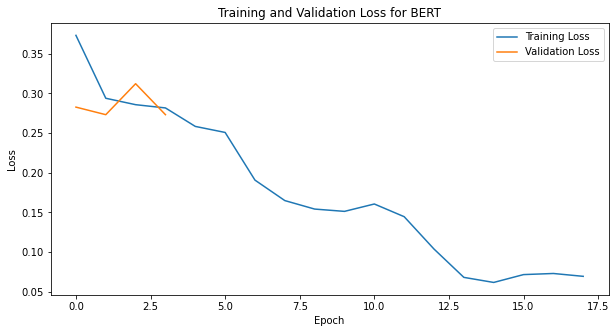

Evaluation Results: {'eval_loss': 0.2731955945491791, 'eval_accuracy': 0.93244, 'eval_precision': 0.9545875031536456, 'eval_recall': 0.90808, 'eval_f1': 0.9307531466524539, 'eval_runtime': 8132.5319, 'eval_samples_per_second': 3.074, 'eval_steps_per_second': 0.384, 'epoch': 3.0}
              precision    recall  f1-score   support

    Negative       0.91      0.96      0.93     12500
    Positive       0.95      0.91      0.93     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000



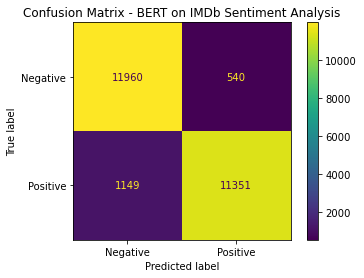

In [5]:
# Step 1: Import Libraries
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import pipeline
from datasets import load_dataset
import numpy as np
import optuna
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 2: Load IMDb Dataset
# This dataset contains movie reviews labeled as positive or negative for sentiment analysis
print("Loading dataset...")
dataset = load_dataset("imdb")

# Step 3: Load Tokenizer and Model
# We use 'bert-base-uncased', a BERT model pretrained with 12 layers and 110M parameters
print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")

# Step 4: Tokenize the Dataset
# Tokenization converts the text data to token IDs that BERT can process
def tokenize_data(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

print("Tokenizing dataset...")
tokenized_dataset = dataset.map(tokenize_data, batched=True)

# Step 5: Define Evaluation Metrics
# We will use accuracy, precision, recall, and F1-score as evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# Step 6: Define Training Arguments
# Here we set essential training parameters
training_args = TrainingArguments(
    output_dir='./results',             # Directory to save model checkpoints
    learning_rate=2e-5,                 # Controls how quickly the model updates weights
    per_device_train_batch_size=8,      # Number of samples processed before updating model
    num_train_epochs=3,                 # Number of full passes through the dataset
    weight_decay=0.01,                  # Regularization term to avoid overfitting
    evaluation_strategy="epoch",        # Evaluate the model at the end of each epoch
    save_strategy="epoch",              # Set save_strategy to match evaluation_strategy
    logging_dir='./logs',               # Directory to save logs for tracking metrics
    load_best_model_at_end=True         # Load the best model based on validation performance
)

# Step 7: Initialize Trainer
# Trainer simplifies the training and evaluation process, allowing us to focus on experimentation
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

# Step 8: Train the Model
print("Training the model...")
trainer.train()

# Step 9: Evaluate Model Performance
print("Evaluating model performance on the test set...")
eval_results = trainer.evaluate()

# Step 10: Plot Training and Validation Loss
# Here we plot the training and validation loss to observe the model's learning behavior
metrics = trainer.state.log_history
train_loss = [x["loss"] for x in metrics if "loss" in x]
eval_loss = [x["eval_loss"] for x in metrics if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for BERT")
plt.legend()
plt.show()

# Step 11: Display Evaluation Metrics
print("Evaluation Results:", eval_results)

# Step 12: Detailed Classification Report
# This step provides accuracy, precision, recall, and F1 for each class
predictions = trainer.predict(tokenized_dataset['test'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids
print(classification_report(true_labels, pred_labels, target_names=["Negative", "Positive"]))

# Step 13: Display Confusion Matrix
# A confusion matrix visualizes the model's predictions against the actual labels
ConfusionMatrixDisplay.from_predictions(true_labels, pred_labels, display_labels=["Negative", "Positive"])
plt.title("Confusion Matrix - BERT on IMDb Sentiment Analysis")
plt.show()


### Storing the trained model

It is wise to store the trained model for later use and comparisons, especially that the training process took a lot of time!

You can include the number of training epochs in the saved model's directory name when saving the model. For example:

This will create a directory like `bert_sentiment_model_3_epochs`, making it easy to identify the number of epochs the model has been trained for.

In [7]:
# Save the model after 3 epochs
epochs_completed = 3
save_path = f"./bert_sentiment_model_{epochs_completed}_epochs"

# Save the model and tokenizer
trainer.save_model("./bert_sentiment_model")  # Specify the directory to save the model
tokenizer.save_pretrained("./bert_sentiment_model")  # Save the tokenizer as well

('./bert_sentiment_model\\tokenizer_config.json',
 './bert_sentiment_model\\special_tokens_map.json',
 './bert_sentiment_model\\vocab.txt',
 './bert_sentiment_model\\added_tokens.json')

## Optional Experimentation Blocks and Exercises

### Exercise 1: Experiment with Different Learning Rates

Objective: Observe how changing the learning rate affects training stability and model performance.

In [ ]:
# Example of experimenting with a higher learning rate
training_args_experiment = TrainingArguments(
    output_dir='./results_experiment',
    learning_rate=5e-5,  # Higher learning rate for experimentation
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs_experiment',
    load_best_model_at_end=True
)

trainer_experiment = Trainer(
    model=model, 
    args=training_args_experiment,
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

# Uncomment below to train with modified learning rate
trainer_experiment.train()

In [ ]:
# Save experimental results:
epochs_completed = 3
save_path = f"./bert_sentiment_model_{3}_epochs_experiment_with_learning_rates"

# Save the model
trainer_experiment.save_model("./bert_sentiment_model")  # Specify the directory to save the model

### Exercise 2: Hyperparameter Optimization with Optuna

Objective: Use Optuna to optimize hyperparameters and find the best configuration for learning_rate, batch_size, and num_epochs.

In [ ]:
def model_objective(trial):
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    num_epochs = trial.suggest_int("num_epochs", 2, 5)
    
    training_args_opt = TrainingArguments(
        output_dir='./results_optuna',
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_dir='./logs_optuna'
    )
    
    trainer_opt = Trainer(
        model=model, 
        args=training_args_opt,
        train_dataset=tokenized_dataset['train'], 
        eval_dataset=tokenized_dataset['test'],
        compute_metrics=compute_metrics
    )
    
    trainer_opt.train()
    eval_results = trainer_opt.evaluate()
    return eval_results["eval_accuracy"]

# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(model_objective, n_trials=5)

print("Best Hyperparameters:", study.best_params)


### Exercise 3: Add a Text Classification Pipeline for Inference

Objective: Create an inference pipeline to classify new text samples after training.

In [ ]:
# Load the fine-tuned model and tokenizer in a pipeline for inference
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Sample inference on new reviews
print(classifier("This movie was fantastic!"))
print(classifier("The plot was terrible and I didn't enjoy it at all."))

### Exercise 4: Loding the saved model for continuation of training process or making comparisons

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

# Load the saved model and tokenizer
saved_model_path = "./bert_sentiment_model"  # Path where the model was saved
model = BertForSequenceClassification.from_pretrained(saved_model_path)
tokenizer = BertTokenizer.from_pretrained(saved_model_path)

### Exercise 4: Perform Evaluation or Inference

Once the model and tokenizer are loaded, you can evaluate the model on the test dataset or use it for predictions:

In [ ]:
from transformers import Trainer

# Reinitialize the Trainer for evaluation or inference
trainer = Trainer(
    model=model, 
    args=training_args,  # Use the same training arguments defined earlier
    eval_dataset=tokenized_dataset['test'], 
    compute_metrics=compute_metrics
)

# Evaluate the loaded model
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

# Use the model for inference (example with raw text)
text = "The movie was fantastic!"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
outputs = model(**inputs)
prediction = np.argmax(outputs.logits.detach().numpy(), axis=1)
print("Predicted Sentiment:", "Positive" if prediction == 1 else "Negative")

### Exercise 5: Continue Training

If you want to resume training from the saved model, simply load it and reinitialize the Trainer with your training dataset.

When resuming training, you need to adjust the num_train_epochs in TrainingArguments to specify how many more epochs you want to train. For instance, if the model was trained for 3 epochs and you want to add 2 more epochs:



In [ ]:
# Update the number of epochs for continued training
additional_epochs = 2
training_args.num_train_epochs = epochs_completed + additional_epochs

# Reinitialize the Trainer with updated training arguments
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

# Continue training
trainer.train()

In [ ]:
# Save the model after the next epochs
epochs_completed = training_args.num_train_epochs
save_path = f"./bert_sentiment_model_{epochs_completed}_epochs"

# Save the model
trainer.save_model("./bert_sentiment_model")  # Specify the directory to save the model

### Notes:

Storage Format: The saved model directory will include:

* pytorch_model.bin: Model weights.
* config.json: Model configuration.
* vocab.txt: Tokenizer vocabulary.

Additional tokenizer files (e.g., tokenizer_config.json).
Model Comparison: Save evaluation results (eval_results) as JSON or text for comparing metrics later. You can also log metrics using tools like TensorBoard or MLFlow.

Version Control: If running multiple experiments, organize saved models into unique directories with meaningful names, e.g., bert_lr_2e-5_epochs_3/.

This workflow allows seamless model saving, loading, evaluation, and fine-tuning.

### Exercise 6: Saving Intermediate Checkpoints

If you want to save the model periodically (e.g., after every epoch), you can specify the save strategy in `TrainingArguments`:


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    save_strategy="epoch",  # Save checkpoint after each epoch
    save_total_limit=3,     # Keep only the 3 most recent checkpoints
    logging_dir='./logs',
    num_train_epochs=5,
)

This will automatically create directories like results/checkpoint-500, results/checkpoint-1000, etc., depending on the number of steps per epoch.

### Exercise 7: Organizing Models with Metadata

For clarity, you can include additional metadata in the directory name, such as the learning rate or dataset:

In [ ]:
# Save model with metadata
learning_rate = 2e-5
dataset_name = "imdb"
save_path = f"./bert_{dataset_name}_{learning_rate}_lr_{epochs_completed}_epochs"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

## Summary

* Custom Save Names: Use formatted strings to include metadata like `epochs`, `learning rate`, or `dataset`.
* Adjust Epochs for Continuation: Update `num_train_epochs` in TrainingArguments based on completed and additional epochs.

This approach ensures that the training process is transparent and reproducible, especially when managing multiple training runs.

## Explanation of Key Steps

Tokenization: Converts raw text into token IDs. Padding ensures sequences in each batch are the same length.
Training: Trainer API simplifies the process with functions for training and evaluation.
Evaluation: Computes metrics, visualizes loss, and displays a confusion matrix to interpret model performance.
Optimization: With Optuna, students can try different combinations of hyperparameters to find the best-performing model.

## Assignments

* Experiment with Different Learning Rates: Adjust the learning rate to see its effect on training convergence.
* Hyperparameter Tuning with Optuna: Use Optuna to automate hyperparameter search and observe the impact of each setting.
* Inference on New Text: Implement a text classification pipeline and test it on custom sentences.
* This setup provides a full workflow for BERT-based text classification, from setup to training, tuning, and evaluation.
* Try train longer with different hyperparameters and compare the achieved results.
* Try to optimize hyperparameters with Optuna and compare the achieved results.
* Add an Inference Pipeline and compare the achieved results.

Send me back the notebook with your solution, presenting your experiments and results in a separate notebook.

## 6. Hyperparameter Optimization with Optuna

In [ ]:

import optuna

def objective(trial):
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    # Define training args
    training_args = TrainingArguments(
        output_dir='./results', 
        learning_rate=learning_rate, 
        per_device_train_batch_size=batch_size, 
        num_train_epochs=2,
        weight_decay=0.01
    )
    trainer = Trainer(
        model=model, 
        args=training_args, 
        train_dataset=tokenized_dataset['train'], 
        eval_dataset=tokenized_dataset['test']
    )
    # Training and evaluation go here...
    # return evaluation metrics

# Uncomment to start Optuna optimization
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=5)


## Conclusion


In this notebook, we've explored various transformer models for text and image tasks. By fine-tuning BERT for sentiment analysis,
ViT for image classification, and optimizing hyperparameters with Optuna, you have gained hands-on experience with modern
transformer-based architectures.

**Further Reading**:
- Hugging Face Transformers documentation
- Papers for BERT, ViT, and other transformer models



## Hyperparameter Explanation and Exercises

Transformers have several important hyperparameters that influence training efficiency and model performance.
Here is an explanation of these hyperparameters, typical ranges, and exercises for students to understand
their impact on transformer models.

### Key Hyperparameters

1. **Learning Rate (`learning_rate`)**
   - **Description**: Controls how much the model weights are adjusted during training. A high learning rate
     can lead to rapid updates and possible divergence, while a very low learning rate may slow down convergence.
   - **Typical Range**: `1e-5` to `5e-4`
   - **Student Exercise**: Experiment with learning rates to find a balance between fast convergence and stable
     training. Observe training losses and validation performance as the rate changes.

2. **Batch Size (`batch_size`)**
   - **Description**: Number of samples processed together before updating the model parameters.
   - **Typical Choices**: 8, 16, 32, or 64. Smaller batch sizes can help avoid memory issues on GPUs.
   - **Student Exercise**: Try different batch sizes to see the effect on training stability, speed, and memory usage.

3. **Number of Epochs (`num_epochs`)**
   - **Description**: The number of complete passes through the dataset during training. More epochs allow more training but can lead to overfitting.
   - **Typical Range**: 2 to 10 epochs
   - **Student Exercise**: Monitor validation performance over epochs to observe if the model starts overfitting,
     and determine an optimal epoch count for early stopping.

4. **Weight Decay (`weight_decay`)**
   - **Description**: Adds a regularization penalty on the model weights to avoid overfitting. Higher values encourage
     smaller weights, potentially preventing overfitting.
   - **Typical Range**: 0 to 0.01
   - **Student Exercise**: Adjust weight decay to observe its effect on the generalization of the model and monitor
     validation accuracy.

### Optimization Exercise with Optuna

Using Optuna, students can try different hyperparameters by defining an objective function, such as maximizing validation
accuracy or minimizing loss. By experimenting with these combinations, they can learn the balance of these hyperparameters
to improve model performance.
